# Breast Thermography 3D Reconstruction (DMR-IR) - Orthographic Geometric Pipeline

**Scope:** Pure geometric 2.5D reconstruction from five segmented thermal views (0 deg, +/-45 deg, +/-90 deg).  
**Goal:** Reconstruct a smooth 3D NURBS-like breast surface and extract asymmetry descriptors for downstream NNMF-ReliefF and Ensemble CNN analysis.  
**Framework:** NumPy + PyTorch + SciPy (edge-computing friendly).

---

## Protocol lock (Moura VISAPP 2024/2025 aligned)

1. Input is a 1-pixel skeletonized contour from semantic segmentation (256x256).
2. Phase 3 uses anatomical anchors (P1, P2, P3) with strict lateral clipping.
3. Phase 4 rotates around anatomical pivots (never camera center).
4. Phase 4 applies **zero Z-translation** after rotation to preserve depth realism.
5. Phase 5 surface interpolation uses high-order B-spline fitting (`kx=5`, `ky=5`) with evaluation step `0.01` in parametric space.
6. Phase 6 outputs numeric geometry features, not only rendered figures.

This notebook includes reference functions that follow these constraints directly.

---

## Phase 1 - Data Loading and Normalization

This phase pairs each thermal TIFF with its binary mask, resizes both to $256 \times 256$, and converts them to tensors suitable for U-Net input.

The thermal image is min-max normalized to preserve temperature contrast while mapping values into a stable learning range:

$$
m_{ij} = \frac{P_{ij} - \min(P)}{\max(P) - \min(P)}
$$

This is equivalent to the paper's normalized intensity step before model training.

In [ ]:
%pip install torch torchvision tifffile


### 1.1 ThermalDataset class

The dataset class performs three important jobs:

1. Finds mask files recursively and uses them as the reference sample list.
2. Locates each TIFF robustly using filename-prefix matching to avoid Unicode mismatches (for example degree-symbol variants).
3. Returns image-mask pairs as shape $(1, H, W)$ tensors so they are immediately compatible with the U-Net input/output format.

This design is intentionally defensive for Windows path and encoding edge cases.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

# ── FIX 2: Reproducibility seed ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)

        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        # Use np.fromfile to bypass Windows encoding issues with the degree symbol (°)
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask file (might be corrupted or empty): {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)


# Paths
TIFF_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\organized_by_patient"
MASK_BASE = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\GroundTruth_Masks"

# ── FIX 1: Train / test split — 78 % / 22 % per paper §3.3 ──────────────────
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
n_total = len(full_dataset)
n_train = int(0.78 * n_total)
n_test  = n_total - n_train
train_set, test_set = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)   # Batch size 2 as per paper
test_loader  = DataLoader(test_set,  batch_size=2, shuffle=False)


Dataset initialized with 162 masks.
Split: 126 train / 36 test  (total=162)


### 1.2 Training-time augmentation

To reduce overfitting on a limited medical dataset, augmentation is applied only to training batches.

- Horizontal flip is applied to both image and mask so spatial correspondence remains correct.
- Brightness jitter is applied only to the thermal image.

This keeps anatomical geometry valid while improving generalization.

In [40]:
# ── FIX 3: Data augmentation ─────────────────────────────────────────────────
def augment(img_tensor, mask_tensor):
    """Random horizontal flip + brightness jitter. Applied to both image and mask."""
    # Random horizontal flip — applied identically to image and mask
    if torch.rand(1).item() > 0.5:
        img_tensor  = TF.hflip(img_tensor)
        mask_tensor = TF.hflip(mask_tensor)

    # Random brightness jitter on image only (masks are binary)
    if torch.rand(1).item() > 0.5:
        factor     = 0.8 + torch.rand(1).item() * 0.4  # uniform in [0.8, 1.2]
        img_tensor = torch.clamp(img_tensor * factor, 0.0, 1.0)

    return img_tensor, mask_tensor


---

## Phase 2 - U-Net Architecture

The model is a 3-level encoder-decoder U-Net with skip connections. Each block uses:

$\text{Conv}(3\times3) \rightarrow \text{ReLU} \rightarrow \text{Conv}(3\times3) \rightarrow \text{ReLU}$

### Channel flow

| Stage | Channels |
|---|---|
| Encoder 1 | 1 -> 64 |
| Encoder 2 | 64 -> 128 |
| Encoder 3 | 128 -> 256 |
| Bottleneck | 256 -> 512 |
| Decoder 3 | 512 -> 256 |
| Decoder 2 | 256 -> 128 |
| Decoder 1 | 128 -> 64 |
| Output | 64 -> 1 (sigmoid) |

The final sigmoid outputs a per-pixel foreground probability map.

In [41]:
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),  # ReLU activator per paper [cite: 135]
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(1, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.bottleneck = conv_block(256, 512)

        # Decoder
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        # Output
        self.out     = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        b  = self.bottleneck(nn.MaxPool2d(2)(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.sigmoid(self.out(d1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = UNet().to(device)
print(f"Model ready on: {device}")


Model ready on: cpu


### 2.1 Dice coefficient metric

Binary cross-entropy is used for optimization, but Dice is the key overlap metric for segmentation quality.

Dice is computed as:

$$
\text{Dice} = \frac{2|A \cap B| + \epsilon}{|A| + |B| + \epsilon}
$$

where $A$ is the thresholded prediction and $B$ is the ground-truth mask.

In [42]:
# ── FIX 4: Dice coefficient ───────────────────────────────────────────────────
def dice_coeff(pred, target, threshold=0.5, eps=1e-6):
    """Soft Dice coefficient. pred and target are (B,1,H,W) float tensors in [0,1]."""
    pred_bin     = (pred > threshold).float()
    intersection = (pred_bin * target).sum()
    return (2.0 * intersection + eps) / (pred_bin.sum() + target.sum() + eps)


---

### 2.2 Training loop (Adam + BCE + early stopping)

| Hyperparameter | Value |
|---|---|
| Loss | Binary Cross-Entropy (BCELoss) |
| Optimizer | Adam |
| Learning rate | $1 \times 10^{-4}$ |
| Batch size | 2 |
| Max epochs | 100 |
| Early stopping patience | 8 epochs without val-Dice improvement |

The loop logs train loss, train Dice, and validation Dice.  
Best validation-Dice weights are saved immediately to avoid losing the strongest checkpoint.

In [ ]:
%pip install tqdm ipywidgets


In [44]:
from tqdm.notebook import tqdm  # Progress bar for Jupyter / VS Code

In [59]:
# Define loss and optimizer per paper specifications
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # Learning rate 1x10^-4 [cite: 136]

num_epochs    = 100   # Total epochs defined in the methodology
patience      = 8    # Stop if no Dice improvement for this many epochs
best_dice     = 0.0
epochs_no_imp = 0
best_ckpt     = "breast_segmentation_unet_best.pth"

print(f"Starting Training on {device}...")
print(f"Early stopping: patience={patience}, monitoring=val Dice\n")

epoch_train_losses = []
epoch_val_dices = []

for epoch in range(num_epochs):
    # ── Training pass ────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    epoch_dice = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

    for imgs, masks in progress_bar:
        imgs, masks = augment(imgs, masks)
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, masks)

        loss.backward()
        optimizer.step()

        current_loss  = loss.item()
        epoch_loss   += current_loss
        epoch_dice   += dice_coeff(output.detach(), masks).item()

        progress_bar.set_postfix(loss=f"{current_loss:.4f}")

    avg_loss = epoch_loss / len(train_loader)
    avg_dice = epoch_dice / len(train_loader)
    
    # ── Validation pass (Dice on held-out test set) ──────────────────────────
    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            val_dice += dice_coeff(model(imgs), masks).item()
    val_dice /= len(test_loader)
    epoch_train_losses.append(avg_loss)
    epoch_val_dices.append(val_dice)

    # ── Logging ──────────────────────────────────────────────────────────────
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:03d}/{num_epochs}] "
              f"Loss: {avg_loss:.4f}  Train Dice: {avg_dice:.4f}  Val Dice: {val_dice:.4f}")

    # ── Early stopping logic ─────────────────────────────────────────────────
    if val_dice > best_dice:
        best_dice     = val_dice
        epochs_no_imp = 0
        torch.save(model.state_dict(), best_ckpt)   # save best weights immediately
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} — "
                  f"no Val Dice improvement for {patience} epochs.")
            print(f"Best Val Dice: {best_dice:.4f}  →  weights saved to '{best_ckpt}'")
            break

# ── Final saves ──────────────────────────────────────────────────────────────
torch.save(model.state_dict(), "breast_segmentation_unet.pth")   # last epoch weights
print(f"\nTraining complete.")
print(f"  Last weights : breast_segmentation_unet.pth")
print(f"  Best weights : {best_ckpt}  (Val Dice: {best_dice:.4f})")

Starting Training on cpu...
Early stopping: patience=8, monitoring=val Dice



Epoch 1/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [001/100] Loss: 0.1537  Train Dice: 0.8083  Val Dice: 0.8057


Epoch 2/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 47/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 48/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 49/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 50/100:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch [050/100] Loss: 0.0764  Train Dice: 0.9133  Val Dice: 0.8495

Early stopping at epoch 50 — no Val Dice improvement for 8 epochs.
Best Val Dice: 0.8539  →  weights saved to 'breast_segmentation_unet_best.pth'

Training complete.
  Last weights : breast_segmentation_unet.pth
  Best weights : breast_segmentation_unet_best.pth  (Val Dice: 0.8539)


#### Optional manual checkpoint

Use this cell when you want an extra named snapshot (for example, after a specific epoch milestone).

This does not replace the best-checkpoint logic; it adds a manual archive point for experiments.

In [46]:
torch.save(model.state_dict(), "breast_segmentation_unet_v1_60epochs.pth")
print("Weights saved successfully!")


Weights saved successfully!


### 2.3 Held-out test evaluation

This section evaluates the trained model on the held-out split (22% test subset).

Reported outputs:

- Mean BCE loss ± standard deviation
- Mean Dice score ± standard deviation

These values summarize both pixel-wise classification quality (BCE) and geometric overlap quality (Dice).

In [60]:
# ── FIX 4: Evaluate on held-out test set ─────────────────────────────────────
model.eval()
test_losses = []
test_dices  = []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        test_losses.append(criterion(preds, masks).item())
        test_dices.append(dice_coeff(preds, masks).item())

print(f"Test BCE  : {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")
print(f"Test Dice : {np.mean(test_dices):.4f}  ± {np.std(test_dices):.4f}")


Test BCE  : 0.1436 ± 0.0589
Test Dice : 0.8495  ± 0.0541


---

### 2.4 Qualitative prediction check

This visualization plots one test sample as:

1. Input thermal image
2. Ground-truth mask
3. U-Net predicted mask

Use it as a quick sanity check before running full inference on all patient views.

In [53]:
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


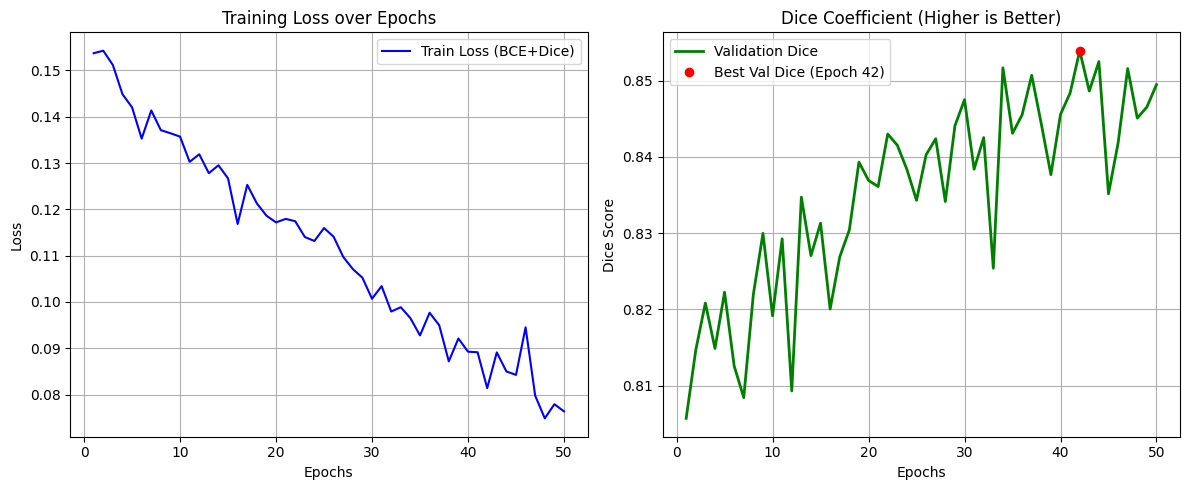

In [61]:
import matplotlib.pyplot as plt

# 1. Visualize the Loss and Dice Scores
def plot_metrics(train_losses, val_dices, train_dices=None):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot 1: BCE Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss (BCE+Dice)')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot 2: Dice Coefficient (Validation vs Train if available)
    plt.subplot(1, 2, 2)
    if train_dices:
        plt.plot(epochs, train_dices, 'b-', label='Train Dice')
    plt.plot(epochs, val_dices, 'g-', label='Validation Dice', linewidth=2)
    
    # Highlight the best epoch
    best_epoch = val_dices.index(max(val_dices)) + 1
    plt.plot(best_epoch, max(val_dices), 'ro', label=f'Best Val Dice (Epoch {best_epoch})')

    plt.title('Dice Coefficient (Higher is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('Dice Score')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Extract the tracked metrics from the training loop variables
# (Assuming you appended the avg_loss and val_dice to lists during the loop)
# Note: You will need to slightly modify the training loop above to append these values to lists:
# e.g., epoch_train_losses.append(avg_loss), epoch_val_dices.append(val_dice)

try:
    plot_metrics(epoch_train_losses, epoch_val_dices)
except NameError:
     print("Could not plot metrics. Ensure you are appending 'avg_loss' and 'val_dice' to lists named 'epoch_train_losses' and 'epoch_val_dices' inside your training loop.")

In [62]:
# 2. Final Model Save Configuration
# The EarlyStopping class already saved the *best* model as "breast_segmentation_unet_best.pth".
# We will explicitly load those best weights and do a final save under a clear V2 name.

print("\\n--- Saving Final Model ---")
final_model_path = "breast_segmentation_unet_best.pth"

try:
    # Load the best weights saved by the early stopper
    model.load_state_dict(torch.load(best_ckpt, weights_only=True))
    
    # Save it explicitly as the V2 model
    torch.save(model.state_dict(), final_model_path)
    print(f"Successfully saved the highest-performing model as: {final_model_path}")
    print(f"You can now use '{final_model_path}' in Phase 3 for automated segmentation.")
except Exception as e:
    print(f"Error during final save: {e}")

\n--- Saving Final Model ---
Successfully saved the highest-performing model as: breast_segmentation_unet_best.pth
You can now use 'breast_segmentation_unet_best.pth' in Phase 3 for automated segmentation.


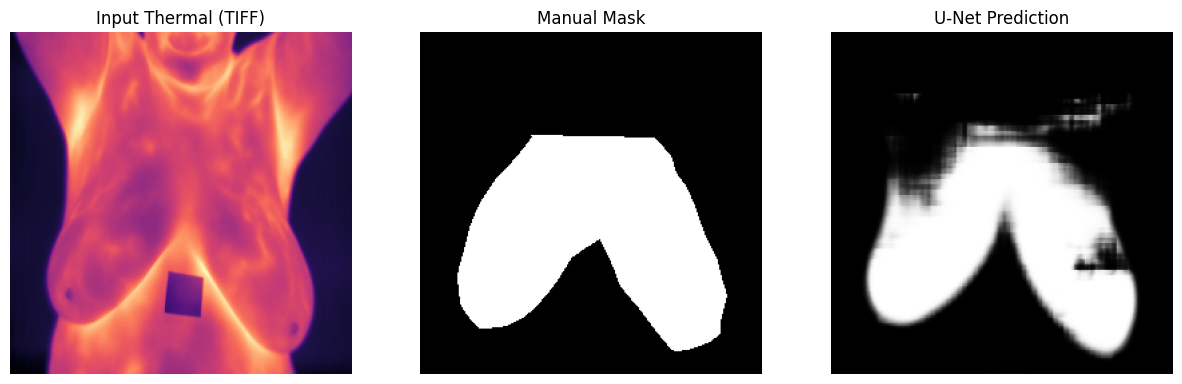

In [86]:
import matplotlib.pyplot as plt
import random

model.eval()
with torch.no_grad():
    # Grab a batch from the test loader
    imgs, masks = next(iter(test_loader))
    imgs = imgs.to(device)

    # Predict
    preds = model(imgs)

    # Plot first item in batch
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(imgs[0, 0].cpu(), cmap='magma')
    axs[0].set_title("Input Thermal (TIFF)")
    axs[1].imshow(masks[0, 0].cpu(), cmap='gray')
    axs[1].set_title("Manual Mask")
    axs[2].imshow(preds[0, 0].cpu(), cmap='gray')
    axs[2].set_title("U-Net Prediction")
    for ax in axs:
        ax.axis('off')
    plt.show()


---

## Inference Pipeline - Automated Segmentation and Edge Extraction

This phase applies the trained U-Net to all TIFF files and saves a clean edge map for each image.

Per image, the pipeline does:

1. Min-max normalization
2. Forward pass through U-Net
3. Threshold at 0.5 to create a binary mask
4. Keep only the largest connected contour (noise suppression)
5. Run Canny edge detection on the cleaned mask
6. Save output as <original_name>_edge.png while preserving folder structure

The edge outputs become the direct input for anchor extraction in Phase 3.

In [74]:
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges2"


In [76]:
def automated_segmentation(model_path, tiff_dir, output_dir):
    # Load the trained model
    # ── FIX 5: weights_only=True avoids FutureWarning in PyTorch ≥ 2.0 ─────
    model = UNet().to(device)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.eval()

    # Find all original TIFFs
    all_tiffs = glob.glob(os.path.join(tiff_dir, "**", "*.tiff"), recursive=True)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Running automated segmentation on {len(all_tiffs)} images...")

    for f_path in tqdm(all_tiffs):
        # 1. Load and Preprocess per paper Eq 1 [cite: 113, 115]
        raw     = tiff.imread(f_path)
        t_min, t_max = np.min(raw), np.max(raw)
        norm    = (raw - t_min) / (t_max - t_min + 1e-8)
        img_256 = cv2.resize(norm.astype(np.float32), (256, 256))

        # 2. U-Net Prediction [cite: 131]
        img_tensor = torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img_tensor).squeeze().cpu().numpy()

        # 3. Suzuki/Binarization Filtering
        binary = (pred > 0.5).astype(np.uint8) * 255

        # 4. Retain Largest Area
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        clean_mask  = np.zeros_like(binary)
        # ── FIX 9: guard — skip save if no contour found ─────────────────────
        if not contours:
            print(f"Warning: no contour found for {os.path.basename(f_path)}, skipping.")
            continue
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean_mask, [largest], -1, 255, thickness=cv2.FILLED)

        # 5. Canny Edge Extraction
        edges = cv2.Canny(clean_mask, 100, 200)

        # Save the finalized edge map
        rel_path  = os.path.relpath(f_path, tiff_dir)
        out_name  = os.path.splitext(rel_path)[0] + "_edge.png"
        save_path = os.path.join(output_dir, out_name)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, edges)


# Run the automation
model_weights = "breast_segmentation_unet_best.pth"
automated_segmentation(model_weights, TIFF_BASE, output_edges)


Running automated segmentation on 657 images...


  0%|          | 0/657 [00:00<?, ?it/s]

---

### Edge-overlay quality check

This section randomly samples generated edge maps and overlays them in green on top of the original thermal image.

Why this is useful:

- Confirms that model boundaries align with anatomical breast contours.
- Quickly reveals failed masks, empty outputs, or corrupted files.
- Verifies that path handling remains stable on Windows/Unicode filenames.

The helper loader is intentionally robust against zero-byte and encoding-related read errors.

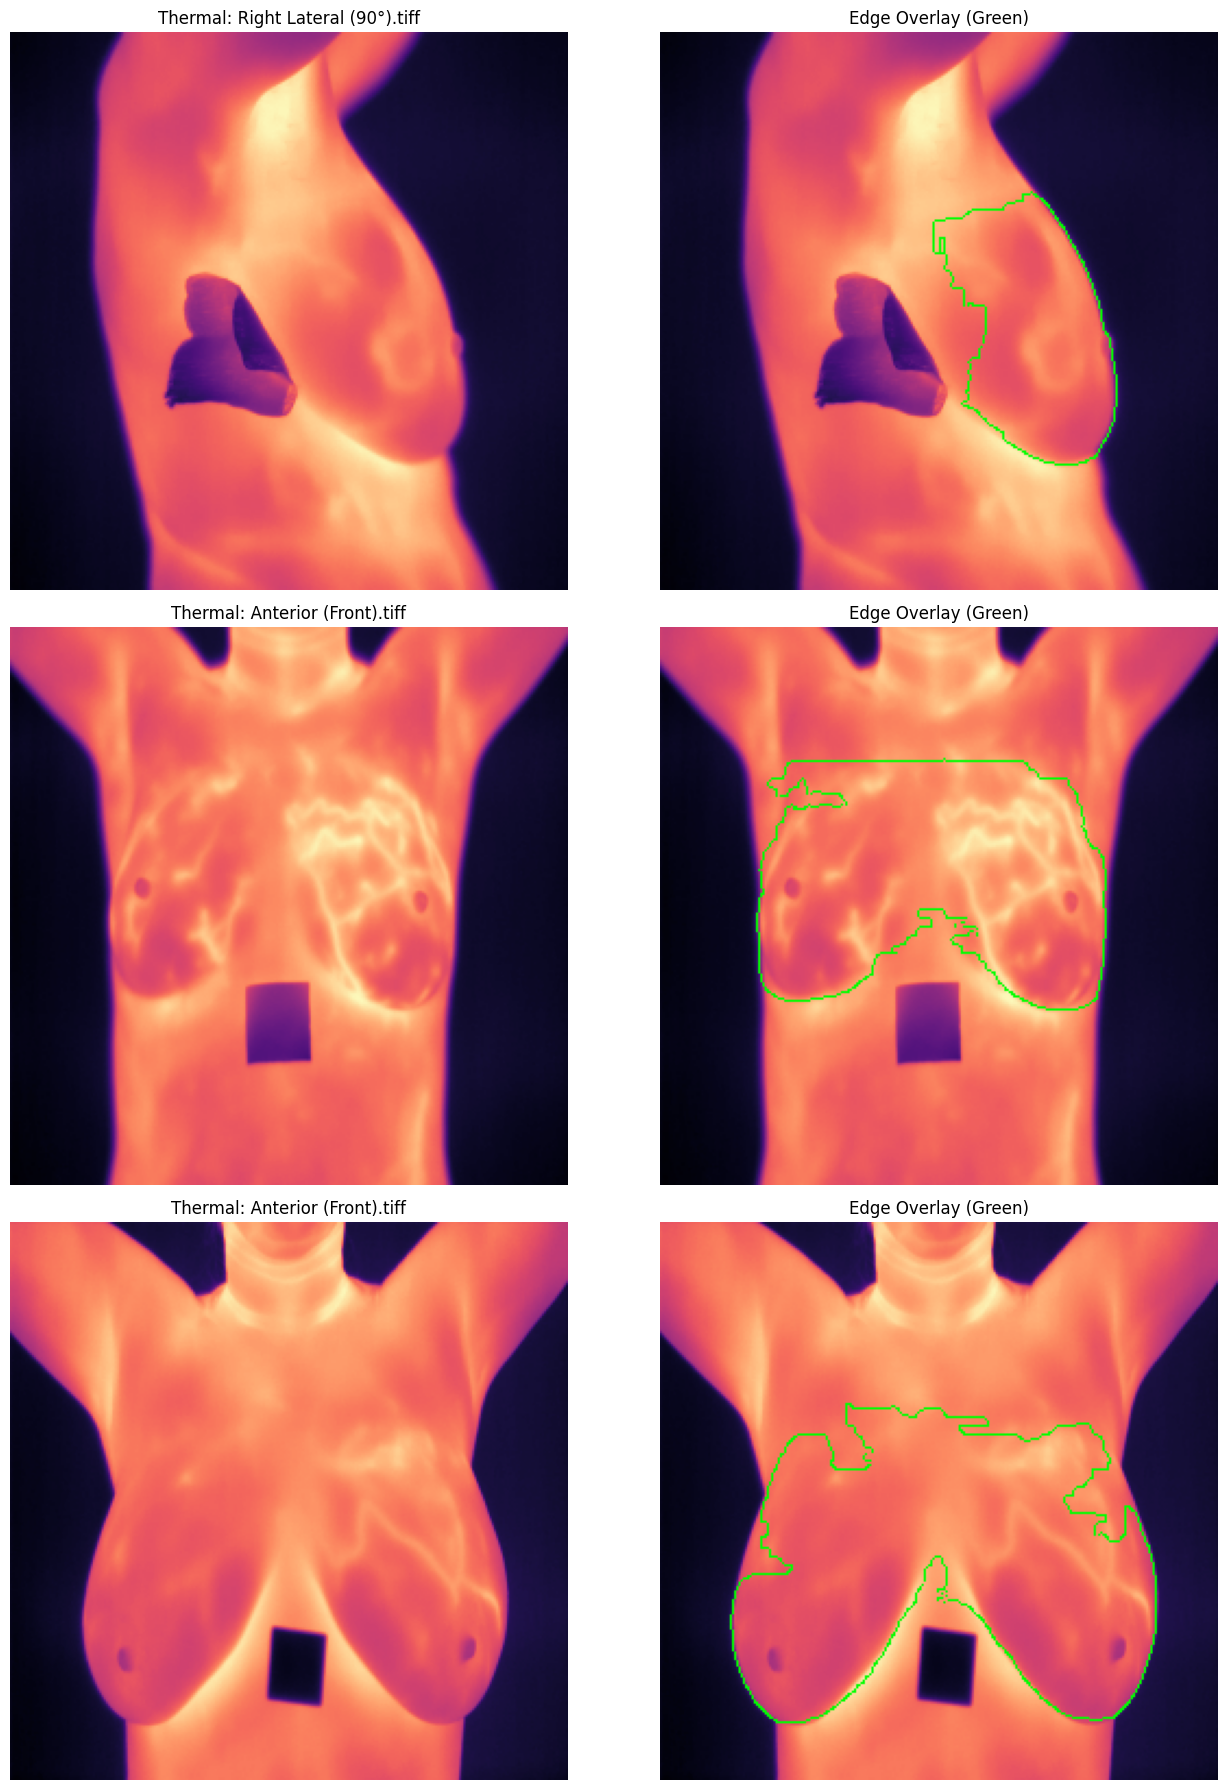

In [81]:
def robust_read_image(path, flags=cv2.IMREAD_GRAYSCALE):
    """Bypasses Windows path encoding issues and handles empty files."""
    try:
        if os.path.getsize(path) == 0:  # Check if file was stopped mid-save
            return None
        # Read file as a numpy array buffer to bypass string encoding
        img_array = np.fromfile(path, dtype=np.uint8)
        img = cv2.imdecode(img_array, flags)
        return img
    except Exception:
        return None


def ultra_robust_light_test(tiff_dir, edge_dir, num_samples=3):
    # 1. Find all generated edge maps
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)

    if not edge_files:
        print("No edge files found! Check your Automated_Edges folder.")
        return

    # 2. Pick samples and setup plotting
    samples = random.sample(edge_files, min(num_samples, len(edge_files)))
    fig, axs = plt.subplots(len(samples), 2, figsize=(14, 6 * len(samples)))
    if len(samples) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, edge_path in enumerate(samples):
        # --- ROBUST READ ---
        edge_img = robust_read_image(edge_path)

        if edge_img is None:
            print(f"Skipping corrupted or unreadable edge map: {os.path.basename(edge_path)}")
            continue

        # 3. Find corresponding TIFF using Prefix Matching
        rel_path          = os.path.relpath(edge_path, edge_dir)
        patient_subfolder = os.path.dirname(rel_path)
        edge_filename     = os.path.basename(rel_path)
        search_folder     = os.path.join(tiff_dir, patient_subfolder)
        search_prefix     = edge_filename.split('(')[0].strip()

        potential_tiffs = glob.glob(os.path.join(search_folder, "*.tiff"))
        tiff_path = next((p for p in potential_tiffs if search_prefix in os.path.basename(p)), None)

        if tiff_path is None:
            continue

        # 4. Load/Normalize TIFF and Resize to 256x256
        raw      = tiff.imread(tiff_path)
        norm     = 255 * (raw - np.min(raw)) / (np.max(raw) - np.min(raw) + 1e-8)
        norm_256 = cv2.resize(norm.astype(np.uint8), (256, 256), interpolation=cv2.INTER_AREA)
        base_display = cv2.applyColorMap(norm_256, cv2.COLORMAP_MAGMA)

        # 5. Overlay edges
        overlay = base_display.copy()
        # The 'if edge_img is not None' check prevents the TypeError
        overlay[edge_img > 0] = [0, 255, 0]

        # Plotting
        axs[i, 0].imshow(cv2.cvtColor(base_display, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_title(f"Thermal: {os.path.basename(tiff_path)}")
        axs[i, 1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_title("Edge Overlay (Green)")
        for ax in axs[i]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()


# Execute the test
ultra_robust_light_test(TIFF_BASE, output_edges, num_samples=3)


---

## Phase 3 - Anchor Extraction (P1, P2, P3)

This phase converts 2D edge maps into anatomical anchor coordinates needed for cross-view 3D registration.

### Anchor meaning

- P1: Right-side anatomical anchor (view-dependent interpretation)
- P2: Inferior/cleavage reference anchor (view-dependent)
- P3: Left-side or chest-wall anchor (view-dependent)

### View-specific extraction logic

- 0 deg frontal: split by image center to detect right/left inferior points and cleavage notch.
- +45 deg right oblique and -45 deg left oblique: treat contour as a single curve; derive anchors without center splitting.
- +90 deg right lateral and -90 deg left lateral: identify profile tip, lowest point, and chest-wall connection.

The result is a CSV table with per-image anchor coordinates and detected view angle.

### Imports for Phases 3 to 5

The next cells load numerical, image-processing, plotting, and CSV utilities required for anchor extraction, registration, and 3D visualization.

### Phase 3 implementation notes (V5 baseline)

This implementation fixes common anchor-assignment failures before moving to the V7 registration flow.

Key corrections in this version:

1. Removes incorrect center-halving for oblique views.
2. Uses signed angles for consistent geometric mapping: right views positive, left views negative.
3. Separates extraction rules for frontal, oblique, and lateral contours.

This makes anchor export more stable and prepares cleaner inputs for paper-aligned registration in later cells.

---

## Strict Reference Implementation (Phase 3 to Phase 6)

The next code cell provides modular functions that follow the protocol exactly:

- `phase3_extract_anchors_strict`: anchor extraction with lateral endpoint-height clipping.
- `phase4_register_curve_strict`: pivot-based orthographic rotation with zero Z translation.
- `phase5_fit_bspline_surface_strict`: degree-5 B-spline surface fitting with optional cylindrical unrolling.
- `phase6_extract_12_asymmetry_indices`: returns 12 geometric asymmetry indices (7 linear, 3 area, 2 volume).

In [ ]:
import numpy as np
import cv2
from scipy.interpolate import bisplrep, bisplev

EPS = 1e-8


def _to_points_xy(edge_img):
    """Return edge points as Nx2 array: [x, y]."""
    y, x = np.where(edge_img > 0)
    if y.size == 0:
        return np.empty((0, 2), dtype=np.float64)
    return np.column_stack((x.astype(np.float64), y.astype(np.float64)))


def _bottom_profile(points_xy):
    """Inferior contour profile: for each x, keep max y."""
    x = points_xy[:, 0].astype(np.int32)
    y = points_xy[:, 1].astype(np.float64)

    order = np.lexsort((y, x))
    x_sorted = x[order]
    y_sorted = y[order]

    ux, idx = np.unique(x_sorted, return_index=True)
    max_y = np.maximum.reduceat(y_sorted, idx)
    return ux.astype(np.float64), max_y.astype(np.float64)


def _skeleton_endpoints(edge_img):
    """Find 1-pixel skeleton endpoints (8-neighborhood degree == 1)."""
    edge = (edge_img > 0).astype(np.uint8)
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]], dtype=np.uint8)
    neighbors = cv2.filter2D(edge, cv2.CV_16S, kernel, borderType=cv2.BORDER_CONSTANT)
    y, x = np.where((edge == 1) & (neighbors == 1))
    if y.size == 0:
        return np.empty((0, 2), dtype=np.float64)
    return np.column_stack((x.astype(np.float64), y.astype(np.float64)))


def _as_xy_tuple(pt):
    return (float(pt[0]), float(pt[1]))


def phase3_extract_anchors_strict(edge_img, view_deg):
    """
    Strict Phase 3 anchor extraction.

    Inputs
    - edge_img: 2D binary/skeleton image (256x256 expected).
    - view_deg: one of {0.0, 45.0, -45.0, 90.0, -90.0}.

    Returns
    - anchors: dict with keys p1, p2, p3 (each (x, y) tuple)
    - meta: dict with clipping diagnostics for lateral views
    """
    view_deg = float(view_deg)
    pts = _to_points_xy(edge_img)
    if pts.shape[0] == 0:
        raise ValueError("No edge points found.")

    h, w = edge_img.shape[:2]
    bx, by = _bottom_profile(pts)
    if bx.size < 3:
        raise ValueError("Insufficient contour support for anchor extraction.")

    center_x = 0.5 * (w - 1)
    meta = {"view": view_deg, "clip_y": np.nan, "points_before": int(pts.shape[0]), "points_after": int(pts.shape[0])}

    # Frontal (0): P1 lowest right-breast (image-left), P2 cleavage notch, P3 lowest left-breast (image-right).
    if view_deg == 0.0:
        margin = int(0.12 * w)
        valid = (bx >= margin) & (bx <= (w - 1 - margin))
        if np.count_nonzero(valid) >= 8:
            bxv, byv = bx[valid], by[valid]
        else:
            bxv, byv = bx, by

        left_mask = bxv < center_x
        right_mask = bxv >= center_x
        if not np.any(left_mask) or not np.any(right_mask):
            raise ValueError("Frontal split failed (missing one side).")

        i1 = np.argmax(byv[left_mask])
        i3 = np.argmax(byv[right_mask])
        p1 = np.array([bxv[left_mask][i1], byv[left_mask][i1]], dtype=np.float64)
        p3 = np.array([bxv[right_mask][i3], byv[right_mask][i3]], dtype=np.float64)

        lo, hi = min(p1[0], p3[0]), max(p1[0], p3[0])
        between = (bxv > lo) & (bxv < hi)
        if np.any(between):
            j = np.argmin(byv[between])
            p2 = np.array([bxv[between][j], byv[between][j]], dtype=np.float64)
        else:
            j = np.argmin(np.abs(bxv - center_x))
            p2 = np.array([bxv[j], byv[j]], dtype=np.float64)

        anchors = {"p1": _as_xy_tuple(p1), "p2": _as_xy_tuple(p2), "p3": _as_xy_tuple(p3)}
        return anchors, meta

    # Obliques (+/-45): P2 cleavage, P1/P3 are lowest points and axis candidates.
    if abs(view_deg) == 45.0:
        margin = int(0.10 * w)
        valid = (bx >= margin) & (bx <= (w - 1 - margin))
        if np.count_nonzero(valid) >= 8:
            bxv, byv = bx[valid], by[valid]
        else:
            bxv, byv = bx, by

        left_mask = bxv < center_x
        right_mask = bxv >= center_x
        if np.any(left_mask):
            il = np.argmax(byv[left_mask])
            low_left = np.array([bxv[left_mask][il], byv[left_mask][il]], dtype=np.float64)
        else:
            k = np.argmax(byv)
            low_left = np.array([bxv[k], byv[k]], dtype=np.float64)

        if np.any(right_mask):
            ir = np.argmax(byv[right_mask])
            low_right = np.array([bxv[right_mask][ir], byv[right_mask][ir]], dtype=np.float64)
        else:
            k = np.argmax(byv)
            low_right = np.array([bxv[k], byv[k]], dtype=np.float64)

        # Enforce protocol pivot usage in Phase 4: +45 pivots on P3, -45 pivots on P1.
        if view_deg == 45.0:
            if low_left[1] >= low_right[1]:
                p3, p1 = low_left, low_right
            else:
                p3, p1 = low_right, low_left
        else:
            if low_left[1] >= low_right[1]:
                p1, p3 = low_left, low_right
            else:
                p1, p3 = low_right, low_left

        lo, hi = min(p1[0], p3[0]), max(p1[0], p3[0])
        between = (bxv >= lo) & (bxv <= hi)
        if np.any(between):
            xb = bxv[between]
            yb = byv[between]
            score = yb + 0.18 * np.abs(xb - center_x)
            j = np.argmin(score)
            p2 = np.array([xb[j], yb[j]], dtype=np.float64)
        else:
            j = np.argmin(np.abs(bxv - center_x))
            p2 = np.array([bxv[j], byv[j]], dtype=np.float64)

        anchors = {"p1": _as_xy_tuple(p1), "p2": _as_xy_tuple(p2), "p3": _as_xy_tuple(p3)}
        return anchors, meta

    # Laterals (+/-90): strict endpoint-height clipping before selecting P2.
    if abs(view_deg) == 90.0:
        endpoints = _skeleton_endpoints(edge_img)
        if endpoints.shape[0] < 2:
            # Fallback: use x-extreme points from all contour points.
            i_min = np.argmin(pts[:, 0])
            i_max = np.argmax(pts[:, 0])
            endpoints = np.vstack([pts[i_min], pts[i_max]])

        if view_deg == 90.0:
            tip = endpoints[np.argmax(endpoints[:, 0])]      # anterior tip
            wall = endpoints[np.argmin(endpoints[:, 0])]     # chest wall
            p1 = tip
            p3 = wall
        else:
            tip = endpoints[np.argmin(endpoints[:, 0])]      # anterior tip
            wall = endpoints[np.argmax(endpoints[:, 0])]     # chest wall
            p1 = wall
            p3 = tip

        clip_y = 0.5 * (tip[1] + wall[1])

        # Remove all points physically higher than endpoint average height.
        # Image y increases downward; "higher" means smaller y.
        keep = pts[:, 1] >= clip_y
        kept = pts[keep]
        if kept.shape[0] == 0:
            kept = pts

        i2 = np.argmax(kept[:, 1])
        p2 = kept[i2]

        meta["clip_y"] = float(clip_y)
        meta["points_after"] = int(kept.shape[0])

        anchors = {"p1": _as_xy_tuple(p1), "p2": _as_xy_tuple(p2), "p3": _as_xy_tuple(p3)}
        return anchors, meta

    raise ValueError(f"Unsupported view_deg={view_deg}. Use one of [0, +/-45, +/-90].")


def phase4_register_curve_strict(points_xy, view_deg, anchors_view, anchors_front):
    """
    Strict Phase 4 registration.

    Rules
    - Rotate around anatomical pivot, never image center.
    - +45 pivot=P3, -45 pivot=P1, +/-90 pivot=P2.
    - Rotate with: X=x*cos(theta), Z=-x*sin(theta)
    - Translate only X and Y to frontal anchor frame.
    - Z translation is always 0.0.

    Returns
    - points_xyz: Nx3 registered points.
    - transform: dict with applied pivot and translations.
    """
    pts = np.asarray(points_xy, dtype=np.float64)
    if pts.ndim != 2 or pts.shape[1] != 2 or pts.shape[0] == 0:
        raise ValueError("points_xy must be an Nx2 array with at least one point.")

    view_deg = float(view_deg)
    theta = np.deg2rad(view_deg)

    p1_f = np.asarray(anchors_front["p1"], dtype=np.float64)
    p2_f = np.asarray(anchors_front["p2"], dtype=np.float64)
    p3_f = np.asarray(anchors_front["p3"], dtype=np.float64)

    pivot_key_map = {
        0.0: "p2",
        45.0: "p3",
        -45.0: "p1",
        90.0: "p2",
        -90.0: "p2",
    }
    if view_deg not in pivot_key_map:
        raise ValueError(f"Unsupported view_deg={view_deg}. Use one of [0, +/-45, +/-90].")

    pivot_key = pivot_key_map[view_deg]

    if view_deg == 0.0:
        pivot = p2_f
        target = p2_f
    else:
        pivot = np.asarray(anchors_view[pivot_key], dtype=np.float64)
        target = np.asarray(anchors_front[pivot_key], dtype=np.float64)

    # Set frontal cleavage as global X-origin reference.
    x_shift = pts[:, 0] - pivot[0]
    x_rot = x_shift * np.cos(theta)
    z_rot = -x_shift * np.sin(theta)

    y_raw = -pts[:, 1]

    tx = target[0] - p2_f[0]
    ty = pivot[1] - target[1]

    x3 = x_rot + tx
    y3 = y_raw + ty
    z3 = z_rot  # strict rule: no Z translation

    points_xyz = np.column_stack((x3, y3, z3))
    transform = {
        "view": view_deg,
        "pivot_key": pivot_key,
        "pivot_xy": (float(pivot[0]), float(pivot[1])),
        "target_xy": (float(target[0]), float(target[1])),
        "tx": float(tx),
        "ty": float(ty),
        "tz": 0.0,
    }
    return points_xyz, transform


def phase5_fit_bspline_surface_strict(
    points_xyz,
    eval_inc=0.01,
    kx=5,
    ky=5,
    smooth=0.0,
    cylindrical_if_wrap=True,
):
    """
    Strict Phase 5 B-spline surface generation.

    Uses scipy.interpolate.bisplrep/bisplev with degree-5 splines.
    If angular wrap is detected, fits in cylindrical domain (theta, Y -> R)
    and wraps back to Cartesian (X, Y, Z).

    eval_inc is applied in normalized parametric space [0, 1].
    """
    pts = np.asarray(points_xyz, dtype=np.float64)
    if pts.ndim != 2 or pts.shape[1] != 3 or pts.shape[0] < (kx + 1) * (ky + 1):
        raise ValueError("Insufficient points for degree-5 bivariate spline fitting.")

    finite = np.isfinite(pts).all(axis=1)
    pts = pts[finite]
    if pts.shape[0] < (kx + 1) * (ky + 1):
        raise ValueError("Not enough finite points for spline fitting.")

    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]

    theta = np.unwrap(np.arctan2(z, x))
    wrap_required = bool(cylindrical_if_wrap and (np.ptp(theta) > np.pi))

    if wrap_required:
        u_raw = theta
        v_raw = y
        w_raw = np.sqrt(x * x + z * z)
        mode = "cylindrical"
    else:
        u_raw = x
        v_raw = y
        w_raw = z
        mode = "cartesian"

    def _normalize(v):
        v0 = float(np.min(v))
        v1 = float(np.max(v))
        span = max(v1 - v0, EPS)
        return (v - v0) / span, v0, span

    u, u0, u_span = _normalize(u_raw)
    v, v0, v_span = _normalize(v_raw)

    tck = bisplrep(u, v, w_raw, kx=kx, ky=ky, s=float(smooth))

    u_eval = np.arange(0.0, 1.0 + 0.5 * eval_inc, eval_inc, dtype=np.float64)
    v_eval = np.arange(0.0, 1.0 + 0.5 * eval_inc, eval_inc, dtype=np.float64)

    w_grid = np.asarray(bisplev(u_eval, v_eval, tck), dtype=np.float64)
    U, V = np.meshgrid(u_eval, v_eval, indexing="ij")

    if mode == "cylindrical":
        theta_grid = U * u_span + u0
        Y = V * v_span + v0
        R = np.maximum(w_grid, 0.0)
        X = R * np.cos(theta_grid)
        Z = R * np.sin(theta_grid)
    else:
        X = U * u_span + u0
        Y = V * v_span + v0
        Z = w_grid

    return {
        "X": X.astype(np.float64),
        "Y": Y.astype(np.float64),
        "Z": Z.astype(np.float64),
        "mode": mode,
        "tck": tck,
        "kx": int(kx),
        "ky": int(ky),
        "eval_inc": float(eval_inc),
    }


def _asymmetry_index(left_value, right_value):
    lv = abs(float(left_value))
    rv = abs(float(right_value))
    return abs(lv - rv) / (lv + rv + EPS)


def _surface_area_and_jacobian_xy(X, Y, Z):
    dXu, dXv = np.gradient(X)
    dYu, dYv = np.gradient(Y)
    dZu, dZv = np.gradient(Z)

    Su = np.stack((dXu, dYu, dZu), axis=-1)
    Sv = np.stack((dXv, dYv, dZv), axis=-1)

    area_density = np.linalg.norm(np.cross(Su, Sv), axis=-1)
    jac_xy = np.abs(dXu * dYv - dXv * dYu)
    return area_density, jac_xy


def phase6_extract_12_asymmetry_indices(X, Y, Z):
    """
    Strict Phase 6 output.

    Returns
    - features: np.ndarray shape (12,)
      [7 linear asymmetry indices, 3 area asymmetry indices, 2 volume asymmetry indices]
    - details: dict of raw left/right metrics
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    Z = np.asarray(Z, dtype=np.float64)

    if not (X.shape == Y.shape == Z.shape):
        raise ValueError("X, Y, Z must have the same shape.")

    left = X < 0.0
    right = X >= 0.0
    if np.count_nonzero(left) < 16 or np.count_nonzero(right) < 16:
        raise ValueError("Surface must contain sufficient points on both left and right sides.")

    def _linear_metrics(mask):
        xs = X[mask]
        ys = Y[mask]
        zs = Z[mask]

        width = np.max(np.abs(xs))
        height = np.ptp(ys)
        depth = np.ptp(zs)
        cx = np.mean(np.abs(xs))
        cy = np.mean(ys)
        cz = np.mean(zs)
        diag = np.sqrt(height * height + depth * depth + width * width)

        return np.array([width, height, depth, cx, cy, cz, diag], dtype=np.float64)

    lin_left = _linear_metrics(left)
    lin_right = _linear_metrics(right)
    linear_asym = np.array([_asymmetry_index(l, r) for l, r in zip(lin_left, lin_right)], dtype=np.float64)

    area_density, jac_xy = _surface_area_and_jacobian_xy(X, Y, Z)

    def _area_metrics(mask):
        z_thr = np.median(Z[mask])
        y_thr = np.median(Y[mask])

        total_area = np.sum(area_density[mask])
        anterior_area = np.sum(area_density[mask & (Z >= z_thr)])
        inferior_area = np.sum(area_density[mask & (Y <= y_thr)])
        return np.array([total_area, anterior_area, inferior_area], dtype=np.float64)

    area_left = _area_metrics(left)
    area_right = _area_metrics(right)
    area_asym = np.array([_asymmetry_index(l, r) for l, r in zip(area_left, area_right)], dtype=np.float64)

    def _volume_metrics(mask):
        z0 = np.min(Z[mask])
        local_depth = np.maximum(Z - z0, 0.0)
        vol_density = local_depth * jac_xy

        total_volume = np.sum(vol_density[mask])
        y_thr = np.median(Y[mask])
        inferior_volume = np.sum(vol_density[mask & (Y <= y_thr)])
        return np.array([total_volume, inferior_volume], dtype=np.float64)

    vol_left = _volume_metrics(left)
    vol_right = _volume_metrics(right)
    volume_asym = np.array([_asymmetry_index(l, r) for l, r in zip(vol_left, vol_right)], dtype=np.float64)

    features = np.concatenate((linear_asym, area_asym, volume_asym), axis=0)

    details = {
        "linear_left": lin_left,
        "linear_right": lin_right,
        "area_left": area_left,
        "area_right": area_right,
        "volume_left": vol_left,
        "volume_right": vol_right,
        "feature_names": [
            "L1_width", "L2_height", "L3_depth", "L4_mean_abs_x", "L5_mean_y", "L6_mean_z", "L7_diagonal",
            "A1_total_surface", "A2_anterior_surface", "A3_inferior_surface",
            "V1_total_volume", "V2_inferior_volume",
        ],
    }
    return features.astype(np.float64), details

In [ ]:
%pip install pandas

In [58]:
import numpy as np
import os
import glob
import cv2
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import math
import random

# Canonical view labels used by alignment stages (Cells 37-39)
VIEW_KEYWORDS = {
    0.0: ["anterior", "front", "frontal", "0"],
    45.0: ["right oblique", "right_oblique"],
    -45.0: ["left oblique", "left_oblique"],
    90.0: ["right lateral", "right_lateral"],
    -90.0: ["left lateral", "left_lateral"],
}

In [38]:
def get_rotation_angle(filename):
    """
    Maps camera angles to geometric space using paper convention.
    Right views are positive, left views are negative.
    """
    name = filename.lower()
    if "frontal" in name or "0°" in name: return 0.0
    elif "right oblique" in name: return 45.0
    elif "left oblique" in name: return -45.0
    elif "right lateral" in name: return 90.0
    elif "left lateral" in name: return -90.0
    return 0.0

def extract_anchors_v5(edge_img, view_deg):
    """
    V5: Safely separates Frontal, Oblique, and Lateral extraction logic.
    """
    y_coords, x_coords = np.where(edge_img > 0)
    if len(y_coords) == 0: return None, None, None

    img_h, img_w = edge_img.shape
    
    # --- Build the Bottom Profile ---
    unique_xs = np.unique(x_coords)
    bottom_profile_x = []
    bottom_profile_y = []
    for x in unique_xs:
        bottom_profile_x.append(x)
        bottom_profile_y.append(np.max(y_coords[x_coords == x]))
        
    bx = np.array(bottom_profile_x)
    by = np.array(bottom_profile_y)

    # ---------------------------------------------------------
    # 1. Frontal View (0°) - Split and find Cleavage
    # ---------------------------------------------------------
    if view_deg == 0.0:
        margin = int(img_w * 0.15)
        valid_mask = (bx > margin) & (bx < (img_w - margin))
        if not np.any(valid_mask): valid_mask = bx > 0
            
        valid_bx, valid_by = bx[valid_mask], by[valid_mask]
        center_x = img_w // 2
        
        # P1: Lowest Right Breast (Left side of image)
        left_mask = valid_bx < center_x
        if not np.any(left_mask): return None, None, None
        p1_idx = np.argmax(valid_by[left_mask])
        p1 = (valid_bx[left_mask][p1_idx], valid_by[left_mask][p1_idx])
        
        # P3: Lowest Left Breast (Right side of image)
        right_mask = valid_bx >= center_x
        if not np.any(right_mask): return None, None, None
        p3_idx = np.argmax(valid_by[right_mask])
        p3 = (valid_bx[right_mask][p3_idx], valid_by[right_mask][p3_idx])
        
        # P2: Cleavage Notch
        between_mask = (valid_bx > p1[0]) & (valid_bx < p3[0])
        if np.any(between_mask):
            p2_idx = np.argmin(valid_by[between_mask])
            p2 = (valid_bx[between_mask][p2_idx], valid_by[between_mask][p2_idx])
        else:
            p2 = (center_x, p1[1])
            
        return p1, p2, p3

    # ---------------------------------------------------------
    # 2. Oblique Views (±45°) - Single Curve Tracing
    # ---------------------------------------------------------
    elif abs(view_deg) == 45.0:
        # Do NOT split the image. Find the absolute lowest point (P2).
        margin = int(img_w * 0.15)
        valid_mask = (bx > margin) & (bx < (img_w - margin))
        if not np.any(valid_mask): valid_mask = bx > 0
        valid_bx, valid_by = bx[valid_mask], by[valid_mask]

        p2_idx = np.argmax(valid_by)
        p2 = (valid_bx[p2_idx], valid_by[p2_idx])

        leftmost_idx = np.argmin(valid_bx)
        rightmost_idx = np.argmax(valid_bx)

        pt_left = (valid_bx[leftmost_idx], valid_by[leftmost_idx])
        pt_right = (valid_bx[rightmost_idx], valid_by[rightmost_idx])

        if view_deg == 45.0: # Right Oblique
            p1, p3 = pt_right, pt_left
        else:                # Left Oblique (-45°)
            p1, p3 = pt_left, pt_right

        return p1, p2, p3

    # ---------------------------------------------------------
    # 3. Lateral Views (±90°) - Chest Wall vs Nipple Tip
    # ---------------------------------------------------------
    elif abs(view_deg) == 90.0:
        if view_deg == 90.0: # Right Lateral (points right)
            margin = int(img_w * 0.40)
            valid_mask = bx > margin
            if not np.any(valid_mask): valid_mask = bx > 0
            valid_bx, valid_by = bx[valid_mask], by[valid_mask]
            
            p1_idx = np.argmax(valid_bx) # Front tip
            p1 = (valid_bx[p1_idx], valid_by[p1_idx])
            
            p2_idx = np.argmax(valid_by) # Lowest point
            p2 = (valid_bx[p2_idx], valid_by[p2_idx])
            
            below_p1_mask = valid_by > p1[1]
            if np.any(below_p1_mask):
                p3_idx = np.argmin(valid_bx[below_p1_mask]) # Chest wall
                p3 = (valid_bx[below_p1_mask][p3_idx], valid_by[below_p1_mask][p3_idx])
            else:
                p3 = (valid_bx[0], valid_by[0])
                
        else: # Left Lateral (-90°)
            margin = int(img_w * 0.60)
            valid_mask = bx < margin
            if not np.any(valid_mask): valid_mask = bx > 0
            valid_bx, valid_by = bx[valid_mask], by[valid_mask]
            
            p1_idx = np.argmin(valid_bx) # Front tip
            p1 = (valid_bx[p1_idx], valid_by[p1_idx])
            
            p2_idx = np.argmax(valid_by) # Lowest point
            p2 = (valid_bx[p2_idx], valid_by[p2_idx])
            
            below_p1_mask = valid_by > p1[1]
            if np.any(below_p1_mask):
                p3_idx = np.argmax(valid_bx[below_p1_mask]) # Chest wall
                p3 = (valid_bx[below_p1_mask][p3_idx], valid_by[below_p1_mask][p3_idx])
            else:
                p3 = (valid_bx[-1], valid_by[-1])
                
        return p1, p2, p3

    return None, None, None

def process_all_edges_to_csv(edge_dir, output_csv):
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)
    results = []
    
    for edge_path in tqdm(edge_files, desc="Extracting V5 Anchors"):
        try:
            if os.path.getsize(edge_path) == 0: continue
            edge_img = cv2.imdecode(np.fromfile(edge_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        except Exception: continue
        if edge_img is None: continue
            
        filename = os.path.basename(edge_path)
        view_deg = get_rotation_angle(filename)
        p1, p2, p3 = extract_anchors_v5(edge_img, view_deg)
        
        if p1 and p2 and p3:
            patient_id = os.path.relpath(edge_path, edge_dir).split(os.sep)[0]
            results.append({
                "Patient_ID": patient_id, "Filename": filename, "View": view_deg,
                "P1_X": p1[0], "P1_Y": p1[1], "P2_X": p2[0], "P2_Y": p2[1], "P3_X": p3[0], "P3_Y": p3[1]
            })
            
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Saved extracted anchors to: {output_csv}")
    return df

# Define paths (Update this to match your system if necessary)
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges2"
coords_csv_path = os.path.join(os.path.dirname(output_edges), "3D_Anchor_Coordinates_V5.csv")

# Execute Data Extraction
if os.path.exists(output_edges):
    extracted_data = process_all_edges_to_csv(output_edges, coords_csv_path)
    display(extracted_data.head())
else:
    print(f"Path not found: {output_edges}")


Extracting V5 Anchors:   0%|          | 0/657 [00:00<?, ?it/s]

Saved extracted anchors to: C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\3D_Anchor_Coordinates_V5.csv


,Patient_ID,Filename,View,P1_X,P1_Y,P2_X,P2_Y,P3_X,P3_Y
0,Patient_1,Anterior (Front)_edge.png,0.0,62,253,126,166,191,252
1,Patient_1,Left Lateral (90Â°)_edge.png,-90.0,36,192,60,229,99,194
2,Patient_1,Left Oblique (45Â°)_edge.png,-45.0,50,182,101,234,185,149
3,Patient_1,Right Lateral (90Â°)_edge.png,90.0,203,207,174,233,137,209
4,Patient_1,Right Oblique (45Â°)_edge.png,45.0,180,210,142,247,74,172


## Phase 3 Visualization and Paper-Aligned Registration

This section explains how each view is transformed into a shared 3D coordinate frame before surface generation.

### Signed-angle convention used in this notebook

- 0 deg: frontal
- +45 deg: right oblique
- -45 deg: left oblique
- +90 deg: right lateral
- -90 deg: left lateral

### Pivot-to-target mapping for cross-view alignment

- +45 deg uses pivot P1 and translates to frontal P3
- -45 deg uses pivot P3 and translates to frontal P1
- +90 deg uses pivot P2 and translates to frontal P3
- -90 deg uses pivot P2 and translates to frontal P1

The registration also keeps the depth rotation sign convention consistent with the implementation:

$$
z_{rot} = -x_{shifted}\sin(\theta)
$$

After canonical per-view curve selection, auxiliary posterior-support curves at +135 deg and -135 deg are generated to stabilize branch-wise surface fitting.

In [2]:
import numpy as np
import os
import glob
import cv2
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import math

def get_rotation_angle(filename):
    name = filename.lower()
    if "frontal" in name or "0°" in name: return 0.0
    elif "right oblique" in name: return 45.0
    elif "left oblique" in name: return -45.0
    elif "right lateral" in name: return 90.0
    elif "left lateral" in name: return -90.0
    return 0.0

def extract_anchors_v7(edge_img, view_deg):
    y_coords, x_coords = np.where(edge_img > 0)
    if len(y_coords) == 0: return None, None, None

    img_h, img_w = edge_img.shape
    # Keep mostly inferior contour points to avoid top-edge anchor artifacts.
    y_cut = np.percentile(y_coords, 45)
    keep_low = y_coords >= y_cut
    if np.count_nonzero(keep_low) > 50:
        y_coords = y_coords[keep_low]
        x_coords = x_coords[keep_low]
    
    # Build Bottom Profile
    unique_xs = np.unique(x_coords)
    bx, by = [], []
    for x in unique_xs:
        bx.append(x)
        by.append(np.max(y_coords[x_coords == x]))
    bx, by = np.array(bx), np.array(by)

    # 1. FRONTAL (0°)
    if view_deg == 0.0:
        cx = img_w // 2
        left_mask = bx < cx
        right_mask = bx >= cx
        
        if not np.any(left_mask) or not np.any(right_mask): return None, None, None
        
        p1_idx = np.argmax(by[left_mask])
        p1 = (bx[left_mask][p1_idx], by[left_mask][p1_idx])
        
        p3_idx = np.argmax(by[right_mask])
        p3 = (bx[right_mask][p3_idx], by[right_mask][p3_idx])
        
        between = (bx > p1[0]) & (bx < p3[0])
        if np.any(between):
            p2_idx = np.argmin(by[between]) # Smallest Y is the highest physical point (cleavage)
            p2 = (bx[between][p2_idx], by[between][p2_idx])
        else:
            p2 = (cx, min(p1[1], p3[1]))
        return p1, p2, p3

    # 2. RIGHT OBLIQUE (+45°)
    elif view_deg == 45.0:
        # P1 is the dominant lowest point (rotational axis for +45).
        p1_idx = np.argmax(by)
        p1 = (bx[p1_idx], by[p1_idx])
        center_x = img_w // 2

        # P3 is the opposite-side chest-wall endpoint.
        if p1[0] < center_x:
            j = np.argmax(bx)
        else:
            j = np.argmin(bx)
        p3 = (bx[j], by[j])

        # P2 is the robust valley between P1 and P3 (reject high spikes).
        lo, hi = min(p1[0], p3[0]), max(p1[0], p3[0])
        between = (bx >= lo) & (bx <= hi)
        if np.any(between):
            xb_b = bx[between]
            by_b = by[between]
            # Exclude endpoints; cleavage should be interior, not chest-wall tip.
            span = max(6, int(0.15 * max(1, hi - lo)))
            interior = (xb_b > (lo + span)) & (xb_b < (hi - span))
            if np.count_nonzero(interior) >= 3:
                xb_i, by_i = xb_b[interior], by_b[interior]
            else:
                xb_i, by_i = xb_b, by_b
            # Prefer high notch (small y) near torso center.
            score = by_i + 0.18 * np.abs(xb_i - center_x)
            k = np.argmin(score)
            p2 = (xb_i[k], by_i[k])
        else:
            p2 = (int((p1[0] + p3[0]) / 2), int(min(p1[1], p3[1])))
        return p1, p2, p3

    # 3. LEFT OBLIQUE (-45°)
    elif view_deg == -45.0:
        # P3 is the dominant lowest point (rotational axis for -45).
        p3_idx = np.argmax(by)
        p3 = (bx[p3_idx], by[p3_idx])
        center_x = img_w // 2

        # P1 is the opposite-side chest-wall endpoint.
        if p3[0] > center_x:
            j = np.argmin(bx)
        else:
            j = np.argmax(bx)
        p1 = (bx[j], by[j])

        # P2 is the robust valley between P1 and P3 (reject high spikes).
        lo, hi = min(p1[0], p3[0]), max(p1[0], p3[0])
        between = (bx >= lo) & (bx <= hi)
        if np.any(between):
            xb_b = bx[between]
            by_b = by[between]
            # Exclude endpoints; cleavage should be interior, not chest-wall tip.
            span = max(6, int(0.15 * max(1, hi - lo)))
            interior = (xb_b > (lo + span)) & (xb_b < (hi - span))
            if np.count_nonzero(interior) >= 3:
                xb_i, by_i = xb_b[interior], by_b[interior]
            else:
                xb_i, by_i = xb_b, by_b
            # Prefer high notch (small y) near torso center.
            score = by_i + 0.18 * np.abs(xb_i - center_x)
            k = np.argmin(score)
            p2 = (xb_i[k], by_i[k])
        else:
            p2 = (int((p1[0] + p3[0]) / 2), int(min(p1[1], p3[1])))
        return p1, p2, p3

    # 4. RIGHT LATERAL (+90°)
    elif view_deg == 90.0:
        p1_idx = np.argmax(bx) # Tip (Rightmost)
        p1 = (bx[p1_idx], by[p1_idx])
        
        p2_idx = np.argmax(by) # Lowest Point (Rotational Axis)
        p2 = (bx[p2_idx], by[p2_idx])
        
        p3_idx = np.argmin(bx) # Chest Wall (Leftmost)
        p3 = (bx[p3_idx], by[p3_idx])
        return p1, p2, p3

    # 5. LEFT LATERAL (-90°)
    elif view_deg == -90.0:
        p3_idx = np.argmin(bx) # Tip (Leftmost)
        p3 = (bx[p3_idx], by[p3_idx])
        
        p2_idx = np.argmax(by) # Lowest Point (Rotational Axis)
        p2 = (bx[p2_idx], by[p2_idx])
        
        p1_idx = np.argmax(bx) # Chest Wall (Rightmost)
        p1 = (bx[p1_idx], by[p1_idx])
        return p1, p2, p3

    return None, None, None

# Export Code
def process_all_edges_to_csv(edge_dir, output_csv):
    edge_files = glob.glob(os.path.join(edge_dir, "**", "*_edge.png"), recursive=True)
    results = []
    
    for edge_path in tqdm(edge_files, desc="Extracting V7 Anchors"):
        try:
            if os.path.getsize(edge_path) == 0: continue
            edge_img = cv2.imdecode(np.fromfile(edge_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        except: continue
        if edge_img is None: continue
            
        filename = os.path.basename(edge_path)
        view_deg = get_rotation_angle(filename)
        p1, p2, p3 = extract_anchors_v7(edge_img, view_deg)
        
        if p1 and p2 and p3:
            patient_id = os.path.relpath(edge_path, edge_dir).split(os.sep)[0]
            results.append({
                "Patient_ID": patient_id, "Filename": filename, "View": view_deg,
                "P1_X": p1[0], "P1_Y": p1[1], "P2_X": p2[0], "P2_Y": p2[1], "P3_X": p3[0], "P3_Y": p3[1]
            })
            
    df = pd.DataFrame(results)
    df.to_csv(output_csv, index=False)
    print(f"Saved extracted anchors to: {output_csv}")
    return df

# Define paths
output_edges = r"C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\Automated_Edges2"
coords_csv_path = os.path.join(os.path.dirname(output_edges), "3D_Anchor_Coordinates_V7.csv")

if os.path.exists(output_edges):
    extracted_data = process_all_edges_to_csv(output_edges, coords_csv_path)

Extracting V7 Anchors:   0%|          | 0/657 [00:00<?, ?it/s]

Saved extracted anchors to: C:\Users\LENOVO THINKPAD T14\Documents\PROPOSAL TA\files\Rodriguez-Guerrero Dataset\Breast Thermography\3D Reconstruction\data\3D_Anchor_Coordinates_V7.csv


---

## Phase 4 - Multi-View Curve Registration (V7)

This stage converts per-view 2D contours into aligned 3D curves for one patient.

### Main steps

1. Read edge maps and extract anchors using V7 logic.
2. Build a cleaned inferior contour for each view.
3. Rotate each curve by its signed view angle.
4. Translate each rotated curve using frontal anchors as reference targets.
5. Select one canonical curve per view.
6. Optionally create auxiliary posterior support curves at +/-135 deg.

### Why this matters

Without registration, each curve exists in its own camera coordinate system.  
After registration, all curves are geometrically comparable and can be used for stable 3D surface fitting.

Applying strict pivot-axis registration for Patient_13...
PM3 depth threshold applied to lateral curves: Z <= 19.00
Frontal file used: Anterior (Front)_edge.png
Selected curves (view -> points):
  -135° -> 63 points (aux_-135)
  -90° -> 83 points (Left Lateral (90Â°)_edge.png)
  -45° -> 139 points (Left Oblique (45Â°)_edge.png)
  +0° -> 173 points (Anterior (Front)_edge.png)
  +45° -> 150 points (Right Oblique (45Â°)_edge.png)
  +90° -> 79 points (Right Lateral (90Â°)_edge.png)
  +135° -> 68 points (aux_+135)


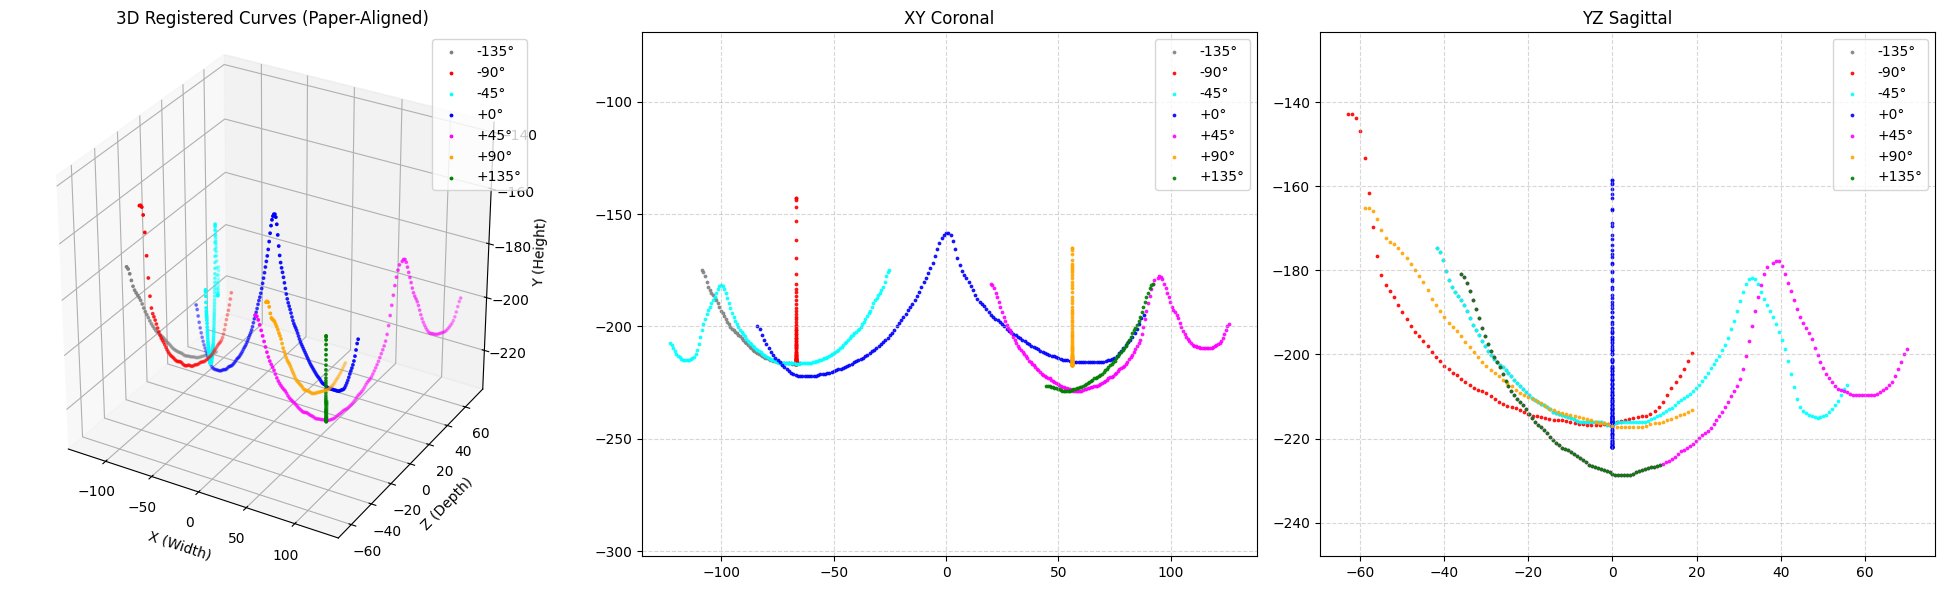

In [4]:
from scipy.ndimage import gaussian_filter1d

def _read_edge_image(path):
    try:
        if os.path.getsize(path) == 0:
            return None
        return cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
    except Exception:
        return None

def _build_single_curve_from_edge(edge_img, p1, p2, p3, neck_margin=20):
    """Convert edge pixels into one clean inferior contour curve (x,y)."""
    y_all, x_all = np.where(edge_img > 0)
    if len(x_all) == 0:
        return None, None

    y_cut = min(p1[1], p2[1], p3[1]) - neck_margin
    keep = y_all >= y_cut
    x_all, y_all = x_all[keep], y_all[keep]
    if len(x_all) < 25:
        return None, None

    ux = np.unique(x_all)
    by = np.array([np.max(y_all[x_all == x]) for x in ux], dtype=np.float64)
    bx = ux.astype(np.float64)

    x_lo, x_hi = np.percentile(bx, [1, 99])
    m = (bx >= x_lo) & (bx <= x_hi)
    bx, by = bx[m], by[m]
    if len(bx) < 20:
        return None, None

    by = gaussian_filter1d(by, sigma=1.2)
    return bx, by

def _map_pivot_target(view_deg, p1, p2, p3, front_p1, front_p3):
    if view_deg == 0.0:
        return (0.0, 0.0), (0.0, 0.0)
    if view_deg == 45.0:
        return p1, front_p3
    if view_deg == -45.0:
        return p3, front_p1
    if view_deg == 90.0:
        return p2, front_p3
    if view_deg == -90.0:
        return p2, front_p1
    return None, None

def _filename_matches_view(filename, view_deg):
    keywords = globals().get("VIEW_KEYWORDS", {})
    kws = keywords.get(view_deg, [])
    fname = filename.lower()
    return any(k in fname for k in kws)

def collect_registered_curves_v7(edge_dir, patient_id, neck_margin=20):
    """Paper-aligned curve registration from 5 views + auxiliary ±135° curves."""
    search_path = os.path.join(edge_dir, patient_id, "**", "*_edge.png")
    patient_files = glob.glob(search_path, recursive=True)
    if not patient_files:
        print(f"No edge files found for {patient_id}")
        return {}

    # Find frontal anchors first.
    front_p1 = front_p2 = front_p3 = None
    frontal_path = None
    for path in patient_files:
        deg = get_rotation_angle(os.path.basename(path))
        if deg != 0.0:
            continue
        img = _read_edge_image(path)
        if img is None:
            continue
        p1, p2, p3 = extract_anchors_v7(img, deg)
        if p1 and p2 and p3:
            front_p1, front_p2, front_p3 = p1, p2, p3
            frontal_path = path
            break

    if front_p2 is None:
        print("Frontal view missing/invalid; cannot register curves.")
        return {}

    global_origin_x = float(front_p2[0])
    front_by_median = float(front_p2[1])
    front_img_ref = _read_edge_image(frontal_path) if frontal_path else None
    if front_img_ref is not None:
        _, front_by_ref = _build_single_curve_from_edge(front_img_ref, front_p1, front_p2, front_p3, neck_margin=neck_margin)
        if front_by_ref is not None and len(front_by_ref) > 0:
            front_by_median = float(np.median(front_by_ref))
    candidates = {0.0: [], 45.0: [], -45.0: [], 90.0: [], -90.0: []}

    for path in patient_files:
        view_deg = get_rotation_angle(os.path.basename(path))
        if view_deg not in candidates:
            continue

        img = _read_edge_image(path)
        if img is None:
            continue

        p1, p2, p3 = extract_anchors_v7(img, view_deg)
        if not (p1 and p2 and p3):
            continue

        bx, by = _build_single_curve_from_edge(img, p1, p2, p3, neck_margin=neck_margin)
        if bx is None:
            continue

        pivot, target = _map_pivot_target(view_deg, p1, p2, p3, front_p1, front_p3)
        if pivot is None:
            continue

        x_shifted = bx if view_deg == 0.0 else (bx - float(pivot[0]))
        ang = math.radians(view_deg)
        x_rot = x_shifted * math.cos(ang)
        z_rot = -x_shifted * math.sin(ang)
        y_rot = -by

        if view_deg == 0.0:
            x_final = x_rot - global_origin_x
            y_final = y_rot
            x_translate = 0.0
            y_offset = 0.0
        else:
            x_translate = float(target[0]) - global_origin_x
            # Align vertical position by contour medians for cross-view consistency.
            y_offset = float(np.median(by) - front_by_median)
            x_final = x_rot + x_translate
            y_final = y_rot + y_offset

        row = {
            "file": os.path.basename(path),
            "view": view_deg,
            "n_points": int(len(x_final)),
            "x": x_final.astype(np.float64),
            "y": y_final.astype(np.float64),
            "z": z_rot.astype(np.float64),
            "x_shifted": x_shifted.astype(np.float64),
            "by": by.astype(np.float64),
            "x_translate": float(x_translate),
            "y_offset": float(y_offset),
            "z_p3": float(-(float(p3[0]) - float(pivot[0])) * math.sin(ang)) if view_deg != 0.0 else 0.0,
        }
        candidates[view_deg].append(row)

    # Canonical per-view selection: prefer filename match, then largest curve.
    best_by_view = {}
    for v, rows in candidates.items():
        if not rows:
            continue
        preferred = [r for r in rows if _filename_matches_view(r["file"], v)]
        pool = preferred if preferred else rows
        best_by_view[v] = max(pool, key=lambda r: r["n_points"])

    # Auxiliary curves from selected obliques only.
    def _make_aux_curve(src, aux_deg):
        rad = math.radians(aux_deg)
        x_aux = src["x_shifted"] * math.cos(rad) + src["x_translate"]
        z_aux = -src["x_shifted"] * math.sin(rad)
        y_aux = -src["by"] + src["y_offset"]

        z_thr = np.quantile(z_aux, 0.55)
        keep = z_aux >= z_thr
        if np.count_nonzero(keep) < 20:
            keep = np.ones_like(z_aux, dtype=bool)

        return {
            "file": f"aux_{aux_deg:+.0f}",
            "view": float(aux_deg),
            "n_points": int(np.count_nonzero(keep)),
            "x": x_aux[keep].astype(np.float64),
            "y": y_aux[keep].astype(np.float64),
            "z": z_aux[keep].astype(np.float64),
        }

    if 45.0 in best_by_view:
        best_by_view[135.0] = _make_aux_curve(best_by_view[45.0], 135.0)
    if -45.0 in best_by_view:
        best_by_view[-135.0] = _make_aux_curve(best_by_view[-45.0], -135.0)

    # Mirror sanity: +45 should normally lie in positive Z half-space.
    if 45.0 in best_by_view and np.median(best_by_view[45.0]["z"]) < 0:
        for k in list(best_by_view.keys()):
            best_by_view[k]["z"] = -best_by_view[k]["z"]
    # Paper Section 4: remove points with Z > PM3, where PM3 is the
    # average Z of P3 from +90 and -90 curves.
    if 90.0 in best_by_view and -90.0 in best_by_view:
        pm3 = 0.5 * (float(best_by_view[90.0].get("z_p3", 0.0)) + float(best_by_view[-90.0].get("z_p3", 0.0)))
        for k in [90.0, -90.0]:
            if k not in best_by_view:
                continue
            zc = best_by_view[k]["z"]
            keep = zc <= pm3
            if np.count_nonzero(keep) < 16:
                continue
            best_by_view[k]["x"] = best_by_view[k]["x"][keep]
            best_by_view[k]["y"] = best_by_view[k]["y"][keep]
            best_by_view[k]["z"] = best_by_view[k]["z"][keep]
            best_by_view[k]["n_points"] = int(np.count_nonzero(keep))
        print(f"PM3 depth threshold applied to lateral curves: Z <= {pm3:.2f}")

    print(f"Frontal file used: {os.path.basename(frontal_path)}")
    print("Selected curves (view -> points):")
    for v in sorted(best_by_view.keys()):
        print(f"  {v:+.0f}° -> {best_by_view[v]['n_points']} points ({best_by_view[v]['file']})")

    return best_by_view

def build_accurate_3d_model_v7(edge_dir, patient_id):
    print(f"Applying strict pivot-axis registration for {patient_id}...")
    curves = collect_registered_curves_v7(edge_dir, patient_id, neck_margin=20)
    if not curves:
        return None

    colors = {
        -135.0: "gray", -90.0: "red", -45.0: "cyan",
         0.0: "blue", 45.0: "magenta", 90.0: "orange", 135.0: "green"
    }

    fig = plt.figure(figsize=(20, 6))
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132)
    ax3 = fig.add_subplot(133)

    for view in sorted(curves.keys()):
        c = colors.get(view, "black")
        x, y, z = curves[view]["x"], curves[view]["y"], curves[view]["z"]
        label = f"{view:+.0f}°"
        ax1.scatter(x, z, y, s=3, c=c, label=label)
        ax2.scatter(x, y, s=3, c=c, alpha=0.85, label=label)
        ax3.scatter(z, y, s=3, c=c, alpha=0.85, label=label)

    ax1.set_title("3D Registered Curves (Paper-Aligned)")
    ax1.set_xlabel("X (Width)")
    ax1.set_ylabel("Z (Depth)")
    ax1.set_zlabel("Y (Height)")
    ax1.set_box_aspect([1, 1, 1])
    ax2.set_title("XY Coronal")
    ax2.set_aspect('equal', adjustable='datalim')
    ax3.set_title("YZ Sagittal")
    ax3.set_aspect('equal', adjustable='datalim')

    for ax in [ax1, ax2, ax3]:
        h, l = ax.get_legend_handles_labels()
        by_label = dict(zip(l, h))
        ax.legend(by_label.values(), by_label.keys(), loc="best")
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    return curves

if os.path.exists(output_edges):
    registered_curves = build_accurate_3d_model_v7(output_edges, "Patient_13")

---

## Phase 5 - Branch-Wise Surface Construction

The final stage builds a geometric breast surface from registered curves using ruled loft strips.

### Surface strategy

- Split geometry into left and right branches around a center X reference.
- Resample each branch curve to consistent point counts.
- Loft strips between neighboring angles in each branch.
- Render the reconstructed surface together with sparse point overlay for sanity checking.

This branch-wise approach reduces cross-branch distortions and is more stable than forcing a single global surface across all views.

PM3 depth threshold applied to lateral curves: Z <= 19.00
Frontal file used: Anterior (Front)_edge.png
Selected curves (view -> points):
  -135° -> 63 points (aux_-135)
  -90° -> 83 points (Left Lateral (90Â°)_edge.png)
  -45° -> 139 points (Left Oblique (45Â°)_edge.png)
  +0° -> 173 points (Anterior (Front)_edge.png)
  +45° -> 150 points (Right Oblique (45Â°)_edge.png)
  +90° -> 79 points (Right Lateral (90Â°)_edge.png)
  +135° -> 68 points (aux_+135)
Registered angles: [-135.0, -90.0, -45.0, 0.0, 45.0, 90.0, 135.0]
Left loft angles used: [-90.0, -45.0, 0.0]
Right loft angles used: [0.0, 45.0, 90.0]
Loft strips generated: left=2, right=2
Center X used for branch split: 2.00
X range: [-122.86, 126.00]
Y range: [-228.67, -142.69]
Z range: [-63.00, 70.00]


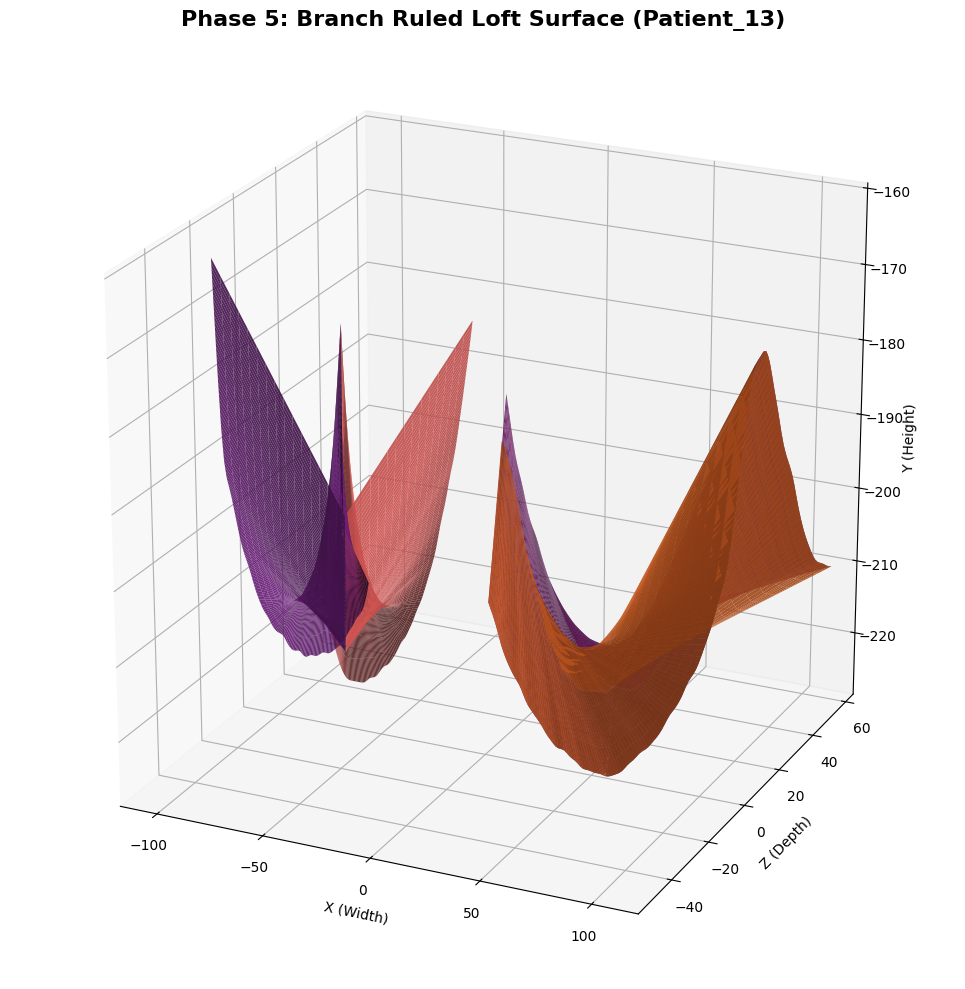

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def generate_nurbs_surface(edge_dir, patient_id, smoothing_factor=1500):
    """
    Phase 5 rewrite: branch-wise ruled lofting between ordered angle curves.
    Keeps Phase 3 (anchors) and Phase 4 (registration) unchanged.
    """
    if "collect_registered_curves_v7" not in globals():
        raise RuntimeError("Run Cell 38 first (it defines collect_registered_curves_v7).")

    curves = collect_registered_curves_v7(edge_dir, patient_id, neck_margin=20)
    if not curves:
        print("No registered curves; aborting surface generation.")
        return

    all_views = [-135.0, -90.0, -45.0, 0.0, 45.0, 90.0, 135.0]
    available = [a for a in all_views if a in curves]
    if len(available) < 3:
        print("Too few curves for ruled loft reconstruction.")
        return

    all_x = np.concatenate([np.asarray(curves[a]["x"], dtype=np.float64) for a in available])
    all_y = np.concatenate([np.asarray(curves[a]["y"], dtype=np.float64) for a in available])
    all_z = np.concatenate([np.asarray(curves[a]["z"], dtype=np.float64) for a in available])
    finite = np.isfinite(all_x) & np.isfinite(all_y) & np.isfinite(all_z)
    all_x, all_y, all_z = all_x[finite], all_y[finite], all_z[finite]
    if len(all_x) == 0:
        print("No finite points available for plotting.")
        return

    center_x = float(np.median(curves[0.0]["x"])) if 0.0 in curves else float(np.median(all_x))

    # Use only measured views for lofting strips (exclude auxiliary ±135 curves).
    left_angles = [a for a in [-90.0, -45.0, 0.0] if a in curves]
    right_angles = [a for a in [0.0, 45.0, 90.0] if a in curves]

    def _to_branch_points(curve, side):
        x = np.asarray(curve["x"], dtype=np.float64)
        y = np.asarray(curve["y"], dtype=np.float64)
        z = np.asarray(curve["z"], dtype=np.float64)
        m = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
        x, y, z = x[m], y[m], z[m]
        if len(x) < 14:
            return None

        if side == "left":
            keep = x <= (center_x - 3.0)
        else:
            keep = x >= (center_x + 3.0)
        x, y, z = x[keep], y[keep], z[keep]
        if len(x) < 12:
            return None

        # Enforce monotonic X ordering for stable cross-view correspondence.
        order = np.argsort(x)
        x, y, z = x[order], y[order], z[order]

        pts = np.column_stack([x, y, z])

        # Remove consecutive duplicates before arc-length parameterization.
        k = np.ones(len(pts), dtype=bool)
        if len(pts) > 1:
            d = np.linalg.norm(np.diff(pts, axis=0), axis=1)
            k[1:] = d > 1e-8
        pts = pts[k]
        if len(pts) < 10:
            return None
        return pts

    def _resample_polyline(pts, n_samples, trim_frac=0.10):
        seg = np.linalg.norm(np.diff(pts, axis=0), axis=1)
        s = np.concatenate([[0.0], np.cumsum(seg)])
        total = s[-1]
        if total <= 1e-8:
            return np.repeat(pts[:1], n_samples, axis=0)

        # Trim unstable endpoints to reduce loft spikes near tips/chest-wall ends.
        lo = trim_frac * total
        hi = (1.0 - trim_frac) * total
        if hi - lo < 1e-5:
            lo, hi = 0.0, total

        t = np.linspace(lo, hi, n_samples)
        xr = np.interp(t, s, pts[:, 0])
        yr = np.interp(t, s, pts[:, 1])
        zr = np.interp(t, s, pts[:, 2])
        return np.column_stack([xr, yr, zr])

    def _prepare_side(angle_list, side, n_samples):
        side_curves = []
        used = []
        for ang in angle_list:
            pts = _to_branch_points(curves[ang], side)
            if pts is None:
                continue
            pts_r = _resample_polyline(pts, n_samples=n_samples, trim_frac=0.10)
            side_curves.append(pts_r)
            used.append(ang)

        if len(side_curves) < 2:
            return [], []

        # Align direction curve-by-curve to maximize correspondence.
        for i in range(1, len(side_curves)):
            prev = side_curves[i - 1]
            cur = side_curves[i]
            d_fwd = np.mean(np.linalg.norm(cur - prev, axis=1))
            d_rev = np.mean(np.linalg.norm(cur[::-1] - prev, axis=1))
            if d_rev < d_fwd:
                side_curves[i] = cur[::-1]
        return side_curves, used

    n_curve_samples = int(max(90, min(180, smoothing_factor // 9)))
    n_loft_steps = int(max(12, min(28, smoothing_factor // 90)))

    left_curves, left_used = _prepare_side(left_angles, "left", n_curve_samples)
    right_curves, right_used = _prepare_side(right_angles, "right", n_curve_samples)

    if len(left_curves) < 2 and len(right_curves) < 2:
        print("Not enough branch curves for ruled lofting.")
        return

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection="3d")

    def _plot_side(side_curves, cmap_name):
        strips = 0
        if len(side_curves) < 2:
            return strips
        cmap = plt.get_cmap(cmap_name)
        for i in range(len(side_curves) - 1):
            c0 = side_curves[i]
            c1 = side_curves[i + 1]
            u = np.linspace(0.0, 1.0, n_loft_steps)

            X = np.empty((n_loft_steps, n_curve_samples), dtype=np.float64)
            Y = np.empty((n_loft_steps, n_curve_samples), dtype=np.float64)
            Z = np.empty((n_loft_steps, n_curve_samples), dtype=np.float64)

            for j, alpha in enumerate(u):
                c = (1.0 - alpha) * c0 + alpha * c1
                X[j, :] = c[:, 0]
                Y[j, :] = c[:, 1]
                Z[j, :] = c[:, 2]

            color = cmap((i + 1) / max(2, len(side_curves)))
            ax.plot_surface(
                X, Z, Y,
                color=color,
                edgecolor="none",
                alpha=0.9,
                antialiased=True,
                rstride=1,
                cstride=1,
            )
            strips += 1
        return strips

    left_strips = _plot_side(left_curves, "magma")
    right_strips = _plot_side(right_curves, "inferno")

    # Light scatter overlay for sanity against registered points.
    ax.scatter(all_x, all_z, all_y, color="white", s=1, alpha=0.02)

    ax.set_title(f"Phase 5: Branch Ruled Loft Surface ({patient_id})", fontsize=16, fontweight="bold")
    ax.set_xlabel("X (Width)")
    ax.set_ylabel("Z (Depth)")
    ax.set_zlabel("Y (Height)")
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlim(np.percentile(all_x, 1), np.percentile(all_x, 99))
    ax.set_ylim(np.percentile(all_z, 1), np.percentile(all_z, 99))
    ax.set_zlim(np.percentile(all_y, 1), np.percentile(all_y, 99))
    ax.view_init(elev=22, azim=-65)

    print(f"Registered angles: {available}")
    print(f"Left loft angles used: {left_used}")
    print(f"Right loft angles used: {right_used}")
    print(f"Loft strips generated: left={left_strips}, right={right_strips}")
    print(f"Center X used for branch split: {center_x:.2f}")
    print(f"X range: [{np.min(all_x):.2f}, {np.max(all_x):.2f}]")
    print(f"Y range: [{np.min(all_y):.2f}, {np.max(all_y):.2f}]")
    print(f"Z range: [{np.min(all_z):.2f}, {np.max(all_z):.2f}]")

    plt.tight_layout()
    plt.show()

if os.path.exists(output_edges):
    generate_nurbs_surface(output_edges, "Patient_13", smoothing_factor=1500)

In [133]:
# Debug: per-view coordinate ranges from Cell 38 registration
for v in sorted(registered_curves.keys()):
    c = registered_curves[v]
    print(
        f"{v:+.0f}° | X[{np.min(c['x']):.1f},{np.max(c['x']):.1f}] ",
        f"Y[{np.min(c['y']):.1f},{np.max(c['y']):.1f}] ",
        f"Z[{np.min(c['z']):.1f},{np.max(c['z']):.1f}] n={len(c['x'])}"
    )

-135° | X[-108.7,-64.9]  Y[-216.9,-174.7]  Z[-41.7,2.1] n=63
-90° | X[-67.0,-67.0]  Y[-216.7,-142.7]  Z[-63.0,19.0] n=83
-45° | X[-122.9,-25.3]  Y[-216.9,-174.7]  Z[-41.7,55.9] n=139
+0° | X[-84.0,88.0]  Y[-222.0,-158.4]  Z[0.0,0.0] n=173
+45° | X[19.9,126.0]  Y[-228.7,-177.7]  Z[-36.1,70.0] n=150
+90° | X[56.0,56.0]  Y[-217.3,-165.2]  Z[-59.0,19.0] n=79
+135° | X[44.7,92.1]  Y[-228.7,-180.9]  Z[-36.1,11.3] n=68


Anterior (Front)_edge.png | angle=+0 | P1=(np.int64(60), np.int64(222)) P2=(np.int64(127), np.int64(158)) P3=(np.int64(183), np.int64(216))
Right Oblique (45Â°)_edge.png | angle=+45 | P1=(np.int64(118), np.int64(233)) P2=(np.int64(170), np.int64(181)) P3=(np.int64(219), np.int64(176))
Left Oblique (45Â°)_edge.png | angle=-45 | P1=(np.int64(52), np.int64(212)) P2=(np.int64(86), np.int64(192)) P3=(np.int64(133), np.int64(228))


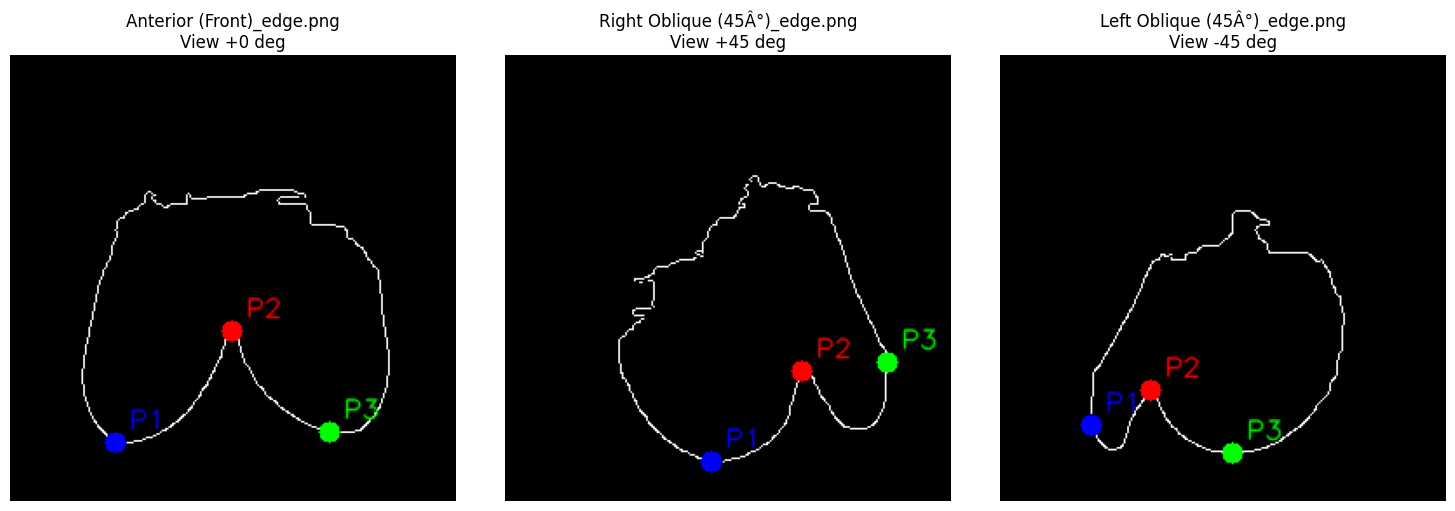

In [6]:
def test_coordinate_extraction_v7(edge_dir, patient_id="Patient_13", max_views=3):
    """Visualize P1/P2/P3 anchors on a few view edge maps for one patient."""
    patient_path = os.path.join(edge_dir, patient_id)
    edge_files = glob.glob(os.path.join(patient_path, "**", "*_edge.png"), recursive=True)
    if not edge_files:
        print(f"No edges found for {patient_id}. Did you generate them?")
        return

    # Prefer a diverse set of views instead of random first files.
    angle_priority = {0.0: 0, 45.0: 1, -45.0: 2, 90.0: 3, -90.0: 4}
    parsed = []
    for f_path in edge_files:
        ang = get_rotation_angle(os.path.basename(f_path))
        parsed.append((ang, f_path))
    parsed.sort(key=lambda t: (angle_priority.get(t[0], 99), os.path.basename(t[1]).lower()))

    selected = []
    used_angles = set()
    # First pass: unique angles.
    for ang, f_path in parsed:
        if ang in used_angles:
            continue
        selected.append((ang, f_path))
        used_angles.add(ang)
        if len(selected) >= max_views:
            break
    # Second pass: fill if not enough.
    if len(selected) < max_views:
        for ang, f_path in parsed:
            if (ang, f_path) in selected:
                continue
            selected.append((ang, f_path))
            if len(selected) >= max_views:
                break

    if not selected:
        print(f"No valid files selected for {patient_id}")
        return

    plt.figure(figsize=(5 * len(selected), 5))
    plotted = 0

    for i, (angle, f_path) in enumerate(selected):
        edge_map = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_GRAYSCALE)
        if edge_map is None:
            continue

        p1, p2, p3 = extract_anchors_v7(edge_map, angle)
        if not (p1 and p2 and p3):
            continue

        img = cv2.imdecode(np.fromfile(f_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if img is None:
            continue

        # P1 blue, P2 red, P3 green (OpenCV BGR).
        cv2.circle(img, (int(p1[0]), int(p1[1])), 6, (255, 0, 0), -1)
        cv2.circle(img, (int(p2[0]), int(p2[1])), 6, (0, 0, 255), -1)
        cv2.circle(img, (int(p3[0]), int(p3[1])), 6, (0, 255, 0), -1)

        cv2.putText(img, "P1", (int(p1[0]) + 8, int(p1[1]) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
        cv2.putText(img, "P2", (int(p2[0]) + 8, int(p2[1]) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
        cv2.putText(img, "P3", (int(p3[0]) + 8, int(p3[1]) - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

        plt.subplot(1, len(selected), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{os.path.basename(f_path)}\nView {angle:+.0f} deg")
        plt.axis("off")

        print(f"{os.path.basename(f_path)} | angle={angle:+.0f} | P1={p1} P2={p2} P3={p3}")
        plotted += 1

    if plotted == 0:
        print(f"No plottable anchors found for {patient_id}")
        return

    plt.tight_layout()
    plt.show()

# Run the anchor sanity test
if os.path.exists(output_edges):
    test_coordinate_extraction_v7(output_edges, patient_id="Patient_13", max_views=3)